Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


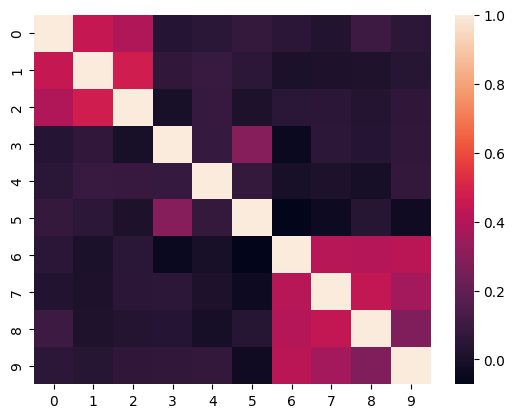

Top matches:
The bowler took a wicket
Virat Kohli scored a century


In [2]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

sentences = [
    "Virat Kohli scored a century",
    "The bowler took a wicket",
    "Cricket is popular in India",

    "Cooking pasta needs boiling water",
    "Spices improve food taste",
    "Baking requires correct temperature",

    "Cybersecurity protects systems",
    "Hackers steal data",
    "Encryption secures information",
    "Firewalls block attacks"
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

similarity = cosine_similarity(embeddings)

sns.heatmap(similarity)
plt.show()

query = "The bowler took three wickets"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = scores.argsort()[-2:][::-1]

print("Top matches:")
for i in top_indices:
    print(sentences[i])